In [1]:
#=============================================================================
# Pipeline:
#   1. Carga y promedio espacial ponderado por área
#   2. Serie mensual y climatología estacional
#   3. Descomposición STL (tendencia + estacionalidad + residuo)
#   4. Tendencia: Sen's slope + Mann-Kendall
#   5. Detección de punto de quiebre (test de Pettitt)
#   6. Figuras publicables

# =============================================================================

In [2]:
pip install pymannkendall 

Note: you may need to restart the kernel to use updated packages.


#### Librerias

In [2]:
# --- Librerías ---
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import STL          # descomposición STL
from pymannkendall import original_test as mk_test # Mann-Kendall
from scipy.stats import theilslopes                # Sen's slope


 Nota sobre las librerías:
 - statsmodels: STL decomposition
 - pymannkendall: test de Mann-Kendall no paramétrico
- scipy.stats.theilslopes: Sen's slope (estimador robusto de tendencia)
 - pyknotted: test de Pettitt para detección de punto de quiebre

#### Celda

In [3]:
# =============================================================================
# CELDA 2 — Paths
# =============================================================================
 
BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

#### Carga y promedio espacial ponderado

In [4]:
# =============================================================================
# CELDA 3 — Paso 1: Carga y promedio espacial ponderado
# =============================================================================
 
# --- Cargar datasets ---
ds_BBI  = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBI_ready.nc"))
ds_BBII = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBII_ready.nc"))
 
def spatial_mean_weighted(ds, varname="ph"):
    """
    Calcula la serie temporal del promedio espacial de una variable,
    ponderando cada celda por el coseno de su latitud.
 
    ¿Por qué ponderar por coseno(lat)?
    En una grilla regular lat-lon, las celdas NO tienen todas el mismo
    tamaño real. A medida que nos acercamos a los polos, los meridianos
    convergen y las celdas son más angostas (menor área). El coseno de
    la latitud aproxima el área relativa de cada celda: cos(-52°) ≈ 0.616
    vs cos(-56°) ≈ 0.559. Sin esta corrección, las celdas más polares
    (más pequeñas) tendrían el mismo peso que las ecuatoriales (más grandes),
    sesgando el promedio.
 
    En nuestro caso la diferencia es pequeña (~4° de extensión latitudinal)
    pero es la práctica estándar en oceanografía y climatología.
 
    Parámetros:
        ds      : xarray.Dataset con coordenadas 'latitude', 'longitude', 'time'
        varname : nombre de la variable a promediar (default: 'ph')
 
    Retorna:
        xarray.DataArray con dimensión 'time' solamente (serie temporal 1D)
    """
    # Calcular pesos: coseno de la latitud en radianes
    # Los NaN del enmascaramiento por polígono son ignorados automáticamente
    # por el método .weighted() de xarray
    weights = np.cos(np.deg2rad(ds["latitude"]))
 
    # Promedio ponderado sobre las dimensiones espaciales
    da_weighted = (
        ds[varname]
        .weighted(weights)
        .mean(dim=["latitude", "longitude"], skipna=True)
    )
 
    return da_weighted
 
 


#### Series temporales mensuales ponderadas - promedios

In [5]:
# Calcular series temporales mensuales ponderadas
ph_BBI_monthly  = spatial_mean_weighted(ds_BBI)
ph_BBII_monthly = spatial_mean_weighted(ds_BBII)
 
# Convertir a DataFrame para facilitar análisis con pandas
df_BBI  = ph_BBI_monthly.to_dataframe(name="pH").reset_index()
df_BBII = ph_BBII_monthly.to_dataframe(name="pH").reset_index()
 
# Agregar columnas útiles
for df in [df_BBI, df_BBII]:
    df["time"]  = pd.to_datetime(df["time"])
    df["year"]  = df["time"].dt.year
    df["month"] = df["time"].dt.month
 
print("=== BBI ===")
print(f"  Período : {df_BBI['time'].iloc[0].date()} → {df_BBI['time'].iloc[-1].date()}")
print(f"  N meses : {len(df_BBI)}")
print(f"  pH min/max/mean: {df_BBI['pH'].min():.4f} / {df_BBI['pH'].max():.4f} / {df_BBI['pH'].mean():.4f}")
 
print("\n=== BBII ===")
print(f"  Período : {df_BBII['time'].iloc[0].date()} → {df_BBII['time'].iloc[-1].date()}")
print(f"  N meses : {len(df_BBII)}")
print(f"  pH min/max/mean: {df_BBII['pH'].min():.4f} / {df_BBII['pH'].max():.4f} / {df_BBII['pH'].mean():.4f}")

=== BBI ===
  Período : 1985-01-01 → 2024-12-01
  N meses : 480
  pH min/max/mean: 8.0200 / 8.1472 / 8.0778

=== BBII ===
  Período : 1985-01-01 → 2024-12-01
  N meses : 480
  pH min/max/mean: 8.0271 / 8.1520 / 8.0768


#### Climatología estacional

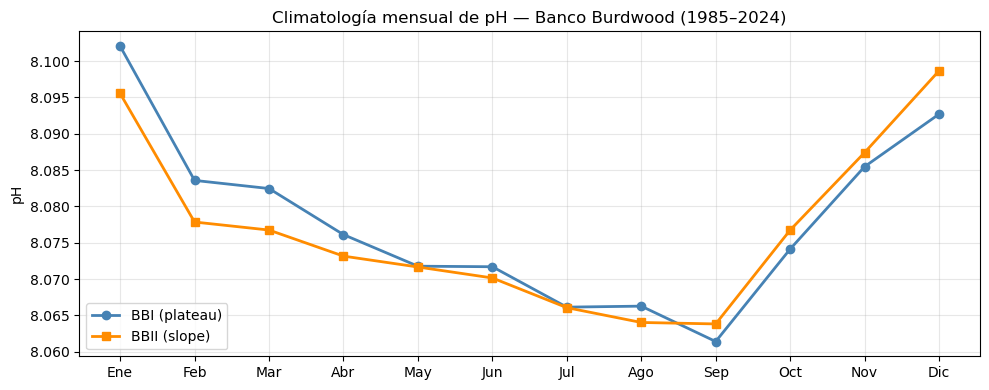

In [6]:
# =============================================================================
# CELDA 4 — Paso 2: Climatología estacional
# =============================================================================
 
# La climatología mensual es el promedio de cada mes calendario
# a lo largo de todo el período (ej: promedio de todos los eneros,
# promedio de todos los febreros, etc.)
# Esto nos muestra el ciclo estacional "típico" del pH en el BB.
 
clim_BBI  = df_BBI.groupby("month")["pH"].mean()
clim_BBII = df_BBII.groupby("month")["pH"].mean()
 
# Graficar climatología
fig, ax = plt.subplots(figsize=(10, 4))
 
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
 
ax.plot(range(1,13), clim_BBI.values,  marker="o", color="steelblue",
        linewidth=2, label="BBI (plateau)")
ax.plot(range(1,13), clim_BBII.values, marker="s", color="darkorange",
        linewidth=2, label="BBII (slope)")
 
ax.set_xticks(range(1,13))
ax.set_xticklabels(meses)
ax.set_ylabel("pH")
ax.set_title("Climatología mensual de pH — Banco Burdwood (1985–2024)")
ax.legend()
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "climatologia_pH.png"), dpi=150)
plt.show()
 

#### Valores numéricos de climatología mensual 

In [7]:
# --- Valores numéricos de climatología mensual ---

# Armar tabla comparativa
clim_tabla = pd.DataFrame({
    "Mes": meses,
    "pH_BBI": clim_BBI.values.round(4),
    "pH_BBII": clim_BBII.values.round(4),
    "Diferencia (BBI-BBII)": (clim_BBI.values - clim_BBII.values).round(4)
})
clim_tabla.index = range(1, 13)

print("=== Climatología mensual de pH (1985–2024) ===\n")
print(clim_tabla.to_string(index=True))

print(f"\n--- Estadísticas ---")
print(f"BBI  — mes más alto: {meses[clim_BBI.values.argmax()]} ({clim_BBI.max():.4f})  |  más bajo: {meses[clim_BBI.values.argmin()]} ({clim_BBI.min():.4f})  |  rango: {(clim_BBI.max()-clim_BBI.min()):.4f}")
print(f"BBII — mes más alto: {meses[clim_BBII.values.argmax()]} ({clim_BBII.max():.4f})  |  más bajo: {meses[clim_BBII.values.argmin()]} ({clim_BBII.min():.4f})  |  rango: {(clim_BBII.max()-clim_BBII.min()):.4f}")

=== Climatología mensual de pH (1985–2024) ===

    Mes  pH_BBI  pH_BBII  Diferencia (BBI-BBII)
1   Ene  8.1021   8.0955                 0.0065
2   Feb  8.0836   8.0778                 0.0057
3   Mar  8.0825   8.0767                 0.0057
4   Abr  8.0761   8.0732                 0.0030
5   May  8.0718   8.0717                 0.0001
6   Jun  8.0717   8.0701                 0.0015
7   Jul  8.0661   8.0661                 0.0001
8   Ago  8.0663   8.0640                 0.0022
9   Sep  8.0614   8.0638                -0.0024
10  Oct  8.0741   8.0767                -0.0026
11  Nov  8.0855   8.0874                -0.0019
12  Dic  8.0927   8.0987                -0.0060

--- Estadísticas ---
BBI  — mes más alto: Ene (8.1021)  |  más bajo: Sep (8.0614)  |  rango: 0.0407
BBII — mes más alto: Dic (8.0987)  |  más bajo: Sep (8.0638)  |  rango: 0.0348


#### Descomposición STL

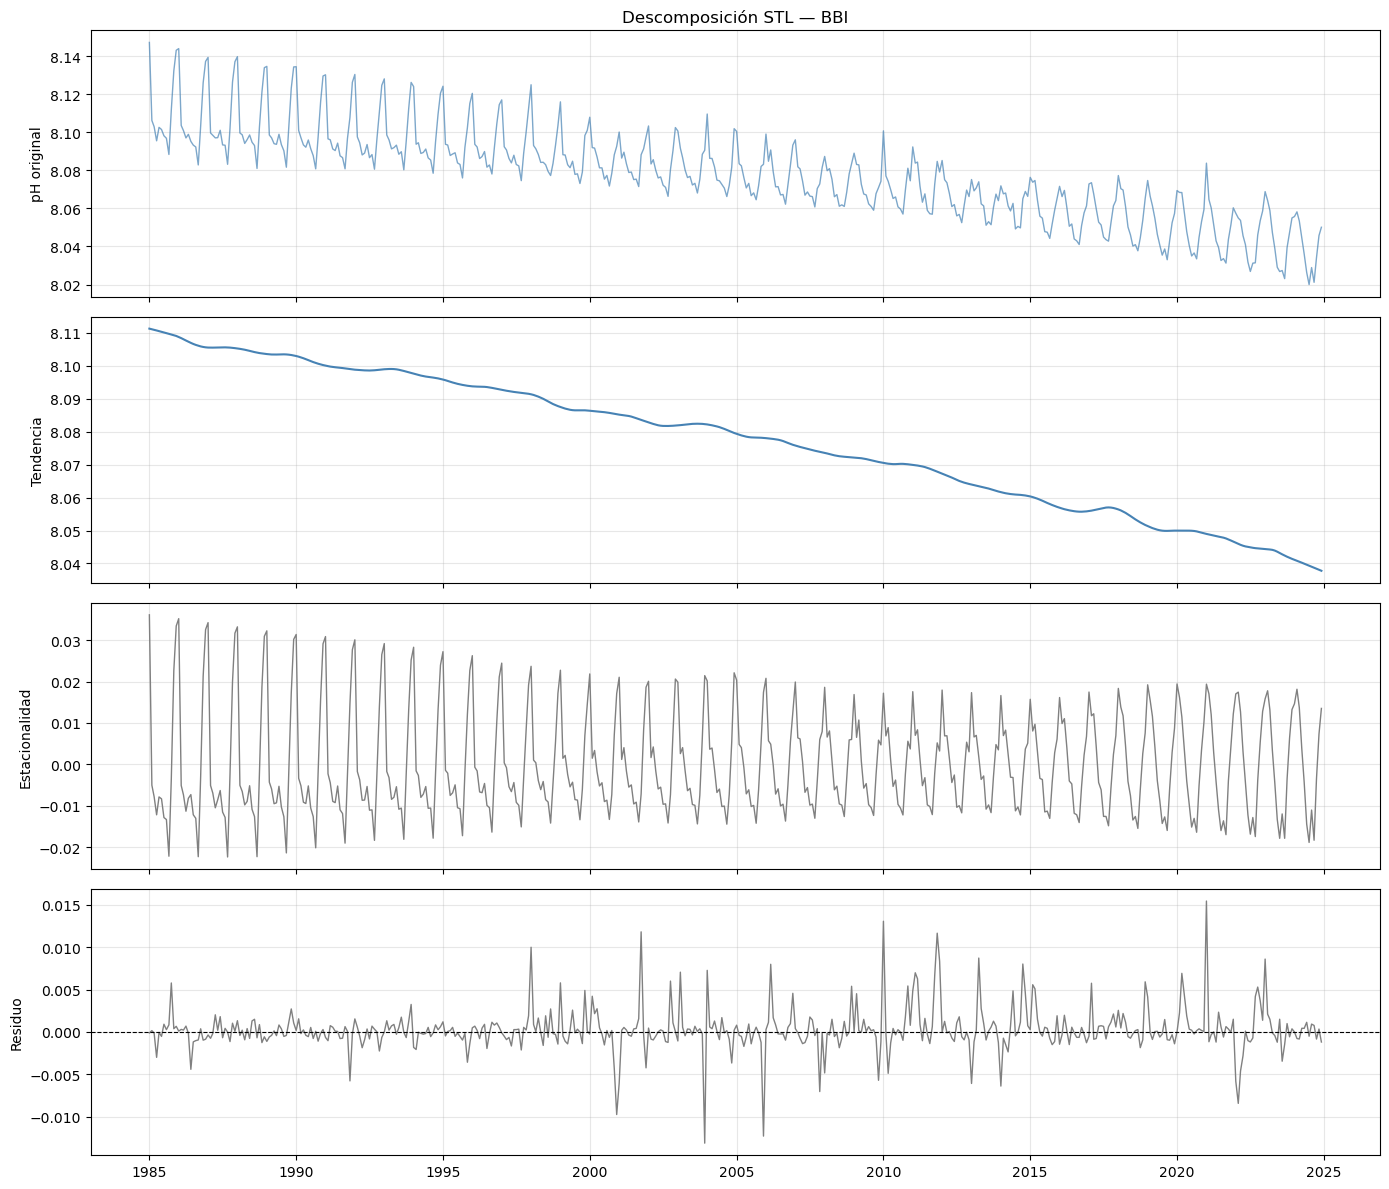

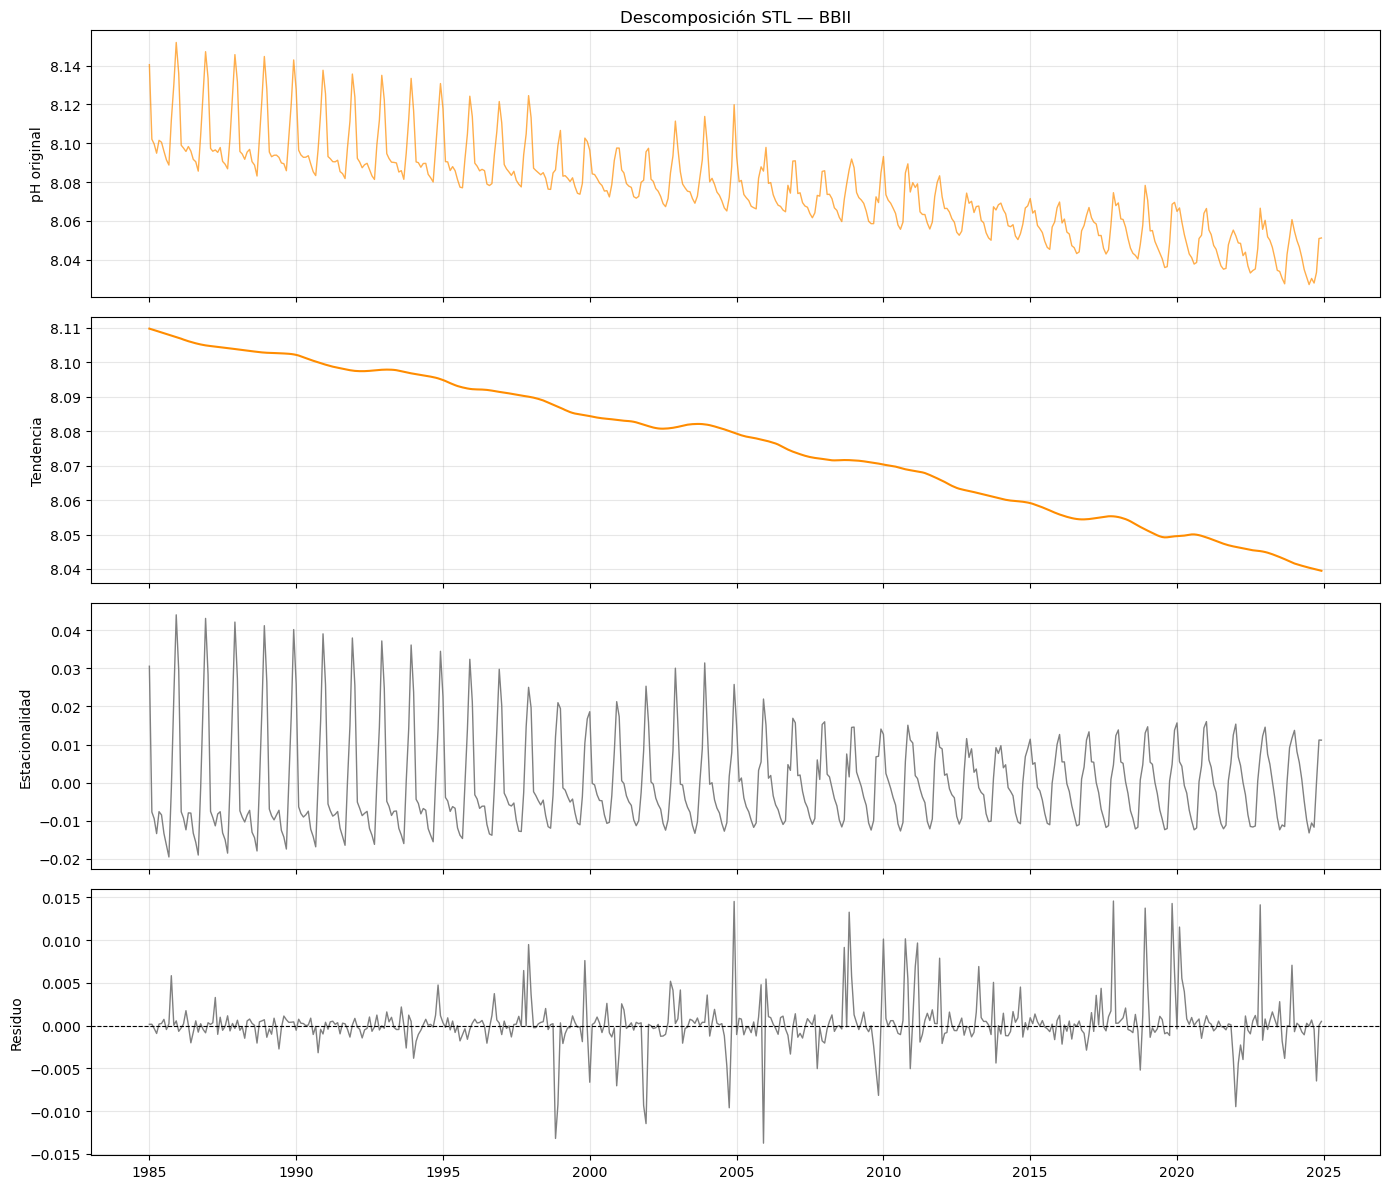

In [8]:
# =============================================================================
# CELDA 5 — Paso 3: Descomposición STL
# =============================================================================
 
# STL (Seasonal-Trend decomposition using LOESS) separa la serie temporal en:
#   - Tendencia   : cambio de largo plazo (lo que nos interesa para el paper)
#   - Estacionalidad : ciclo estacional repetitivo (verano/invierno)
#   - Residuo     : variabilidad que no explican los dos anteriores
#
# Por qué STL y no simplemente promedios anuales?
# Porque la estacionalidad del pH es muy marcada (~0.05–0.10 unidades de
# amplitud). Si no la removemos, puede enmascarar o distorsionar la tendencia
# de largo plazo. STL es el método estándar actual en oceanografía.
#
# period=12 porque los datos son mensuales y el ciclo es anual.
 
def run_stl(df, col="pH", period=12):
    """
    Aplica descomposición STL a una serie temporal mensual.
 
    Parámetros:
        df     : DataFrame con columna de tiempo y pH
        col    : nombre de la columna de la variable
        period : período estacional (12 para datos mensuales)
 
    Retorna:
        stl_result : objeto con atributos .trend, .seasonal, .resid
        df_out     : DataFrame con las tres componentes añadidas
    """
    series = df.set_index("time")[col].asfreq("MS")  # frecuencia mensual explícita
 
    stl = STL(series, period=period, robust=True)
    # robust=True hace el ajuste robusto a outliers (recomendado)
    result = stl.fit()
 
    df_out = df.copy()
    df_out["trend"]    = result.trend.values
    df_out["seasonal"] = result.seasonal.values
    df_out["residual"] = result.resid.values
 
    return result, df_out
 
 
stl_BBI,  df_BBI_stl  = run_stl(df_BBI)
stl_BBII, df_BBII_stl = run_stl(df_BBII)
 
# --- Graficar descomposición STL ---
def plot_stl(df_stl, region_name, color="steelblue"):
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
 
    axes[0].plot(df_stl["time"], df_stl["pH"],      color=color, alpha=0.7, lw=1)
    axes[0].set_ylabel("pH original")
    axes[0].set_title(f"Descomposición STL — {region_name}")
 
    axes[1].plot(df_stl["time"], df_stl["trend"],   color=color, lw=1.5)
    axes[1].set_ylabel("Tendencia")
 
    axes[2].plot(df_stl["time"], df_stl["seasonal"], color="gray", lw=1)
    axes[2].set_ylabel("Estacionalidad")
 
    axes[3].plot(df_stl["time"], df_stl["residual"], color="gray", lw=1)
    axes[3].axhline(0, color="black", lw=0.8, linestyle="--")
    axes[3].set_ylabel("Residuo")
 
    for ax in axes:
        ax.grid(alpha=0.3)
 
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"STL_{region_name}.png"), dpi=150)
    plt.show()
 
 
plot_stl(df_BBI_stl,  "BBI",  color="steelblue")
plot_stl(df_BBII_stl, "BBII", color="darkorange")

#### Tendencia — Sen's slope + Mann-Kendall

In [10]:
#=============================================================================
# CELDA 6 — Paso 4: Tendencia — Sen's slope + Mann-Kendall
# =============================================================================
 
# Trabajamos sobre la componente de TENDENCIA del STL (no sobre la serie cruda)
# porque queremos la tasa de cambio libre de estacionalidad.
#
# Sen's slope:
#   Estimador robusto de la tasa de cambio lineal. A diferencia de OLS
#   (regresión lineal clásica), no asume normalidad y no es sensible a
#   outliers. Es el estándar en estudios de tendencias oceanográficas.
#   Unidades: pH/mes → lo convertimos a pH/año y pH/década.
#
# Test de Mann-Kendall:
#   Test no paramétrico que evalúa si existe una tendencia monótona
#   (consistentemente ascendente o descendente) en la serie.
#   H0: no hay tendencia. Si p < 0.05, rechazamos H0.
#   No asume distribución normal de los datos.
 
def compute_trend(df_stl, region_name):
    """
    Calcula Sen's slope y test de Mann-Kendall sobre la tendencia STL.
 
    Reporta:
        - Tasa de cambio en pH/año y pH/década
        - Significancia estadística (p-valor y nivel)
        - Intervalo de confianza de Sen's slope
    """
    trend_series = df_stl["trend"].dropna().values
 
    # Índice numérico en meses (0, 1, 2, ...)
    x = np.arange(len(trend_series))
 
    # --- Sen's slope ---
    # theilslopes retorna: (slope, intercept, low_slope, high_slope)
    # donde low/high son los límites del IC al 95%
    slope, intercept, low_slope, high_slope = theilslopes(trend_series, x)
 
    # Convertir de pH/mes a pH/año y pH/década
    slope_yr  = slope * 12
    slope_dec = slope * 120
    low_yr    = low_slope * 12
    high_yr   = high_slope * 12
 
    # --- Mann-Kendall ---
    mk_result = mk_test(trend_series)
 
    print(f"\n{'='*55}")
    print(f"  TENDENCIA — {region_name}")
    print(f"{'='*55}")
    print(f"  Sen's slope  : {slope_yr:.5f} pH/año")
    print(f"               : {slope_dec:.4f} pH/década")
    print(f"  IC 95%       : [{low_yr:.5f}, {high_yr:.5f}] pH/año")
    print(f"  Mann-Kendall : {mk_result.trend}")
    print(f"  p-valor      : {mk_result.p:.4e}")
    print(f"  Significancia: {'*** p<0.001' if mk_result.p < 0.001 else '** p<0.01' if mk_result.p < 0.01 else '* p<0.05' if mk_result.p < 0.05 else 'no significativa'}")
 
    return {
        "region"    : region_name,
        "slope_yr"  : slope_yr,
        "slope_dec" : slope_dec,
        "IC_low_yr" : low_yr,
        "IC_high_yr": high_yr,
        "mk_trend"  : mk_result.trend,
        "mk_p"      : mk_result.p,
        "intercept" : intercept,
        "slope_raw" : slope,
        "x"         : x,
    }
 
 
results_BBI  = compute_trend(df_BBI_stl,  "BBI")
results_BBII = compute_trend(df_BBII_stl, "BBII")
 


  TENDENCIA — BBI
  Sen's slope  : -0.00173 pH/año
               : -0.0173 pH/década
  IC 95%       : [-0.00175, -0.00172] pH/año
  Mann-Kendall : decreasing
  p-valor      : 0.0000e+00
  Significancia: *** p<0.001

  TENDENCIA — BBII
  Sen's slope  : -0.00172 pH/año
               : -0.0172 pH/década
  IC 95%       : [-0.00173, -0.00170] pH/año
  Mann-Kendall : decreasing
  p-valor      : 0.0000e+00
  Significancia: *** p<0.001


#### Cálculo de anomalías

In [17]:
def compute_anomalies(df):
    """
#     Calcula anomalías mensuales restando la climatología de cada mes.
#     Ej: el valor de enero 2010 menos el promedio de todos los eneros.
#     """
    clim = df.groupby("month")["pH"].mean()
    df = df.copy()
    df["anomaly"] = df["pH"] - df["month"].map(clim)
    return df
 
 
df_BBI_anom  = compute_anomalies(df_BBI)
df_BBII_anom = compute_anomalies(df_BBII)

#### NO SE USA Detección de punto de quiebre (Test de Pettitt) 

In [13]:
# NO SE USA =============================================================================
# CELDA 7 — Paso 5: Detección de punto de quiebre (Test de Pettitt) 
# =============================================================================
 
# El test de Pettitt detecta el punto en el tiempo donde la serie
# cambia de manera más abrupta (cambio en la media).
# Es no paramétrico y muy usado en series hidrológicas y oceanográficas.
# H0: no hay punto de cambio. Si p < 0.05, hay un cambio significativo.
#
# Aplicamos sobre las ANOMALÍAS mensuales (serie original - climatología)
# para que el resultado no esté influenciado por la estacionalidad.
 
def compute_anomalies(df):
    """
#     Calcula anomalías mensuales restando la climatología de cada mes.
#     Ej: el valor de enero 2010 menos el promedio de todos los eneros.
#     """
    clim = df.groupby("month")["pH"].mean()
     df = df.copy()
     df["anomaly"] = df["pH"] - df["month"].map(clim)
     return df
 
 
 df_BBI_anom  = compute_anomalies(df_BBI)
 df_BBII_anom = compute_anomalies(df_BBII)
 
 
# def pettitt_test(series):
#     """
#     Implementación del test de Pettitt.
#     Retorna el índice del punto de cambio y el p-valor aproximado.
#     """
#     n = len(series)
#     U = np.zeros(n)
#     for t in range(1, n):
#         U[t] = U[t-1] + np.sum(np.sign(series[t] - series[:t]))
 
#     K = np.max(np.abs(U))
#     t_change = np.argmax(np.abs(U))
 
#     # p-valor aproximado (fórmula de Pettitt 1979)
#     p = 2 * np.exp(-6 * K**2 / (n**3 + n**2))
 
#     return t_change, K, p
 
 
# def report_pettitt(df_anom, region_name):
#     series = df_anom["anomaly"].dropna().values
#     times  = df_anom["time"].values
 
#     t_idx, K, p = pettitt_test(series)
#     t_change = pd.Timestamp(times[t_idx])
 
#     print(f"\n{'='*55}")
#     print(f"  PETTITT — {region_name}")
#     print(f"{'='*55}")
#     print(f"  Punto de cambio : {t_change.strftime('%Y-%m')}")
#     print(f"  Estadístico K   : {K:.1f}")
#     print(f"  p-valor         : {p:.4e}")
#     print(f"  Significancia   : {'*** p<0.001' if p < 0.001 else '** p<0.01' if p < 0.01 else '* p<0.05' if p < 0.05 else 'no significativa'}")
 
#     return t_change, p
 
 
# t_change_BBI,  p_BBI  = report_pettitt(df_BBI_anom,  "BBI")
# t_change_BBII, p_BBII = report_pettitt(df_BBII_anom, "BBII")

#### Reemplazo del test de Pettitt por CUSUM + comparación de períodos

In [18]:
# Reemplazo del test de Pettitt por CUSUM + comparación de períodos
# =============================================================================
# Por qué CUSUM en lugar de Pettitt?
#   - Pettitt detecta cambios ABRUPTOS en la media (saltos)
#   - Nuestra serie muestra una transición GRADUAL de anomalías positivas
#     a negativas → Pettitt no es apropiado
#   - CUSUM (Cumulative Sum) acumula las anomalías en el tiempo:
#       * Cuando sube → la serie está consistentemente por ENCIMA de la media
#       * Cuando baja → la serie está consistentemente por DEBAJO de la media
#       * El punto de inflexión (máximo del CUSUM) es cuando la serie
#         cruza de un régimen al otro → ese es nuestro punto de cambio
#   - Es mucho más apropiado para transiciones graduales y muy usado
#     en oceanografía y climatología
# =============================================================================
 
 
# =============================================================================
# CELDA A — Cálculo del CUSUM y detección del punto de cambio
# =============================================================================
 
from scipy import stats
 
def compute_cusum(df_anom, region_name):
    """
    Calcula el CUSUM (Cumulative Sum) de las anomalías de pH.
 
    El CUSUM se define como la suma acumulada de las anomalías:
        CUSUM(t) = sum(anomaly_i) para i = 1 ... t
 
    Interpretación:
        - Pendiente positiva → período con pH sistemáticamente ALTO
        - Pendiente negativa → período con pH sistemáticamente BAJO
        - Punto de inflexión (máximo) → cambio de régimen
 
    El punto de cambio se detecta como el máximo absoluto del CUSUM,
    que corresponde al momento donde la acumulación cambia de dirección.
    """
    anomalies = df_anom["anomaly"].values
    times     = df_anom["time"].values
 
    # Calcular CUSUM
    cusum = np.cumsum(anomalies)
 
    # Detectar punto de cambio: índice del máximo absoluto del CUSUM
    # (donde la curva cambia de subir a bajar, o viceversa)
    idx_change = np.argmax(cusum)
    t_change   = pd.Timestamp(times[idx_change])

    print(f"\n{'='*55}")
    print(f"  CUSUM — {region_name}")
    print(f"{'='*55}")
    print(f"  Punto de cambio de régimen: {t_change.strftime('%Y-%m')}")
    print(f"  CUSUM en ese punto        : {cusum[idx_change]:.4f}")

    return cusum, idx_change, t_change, times
 
 
cusum_BBI,  idx_BBI,  t_change_BBI,  times_BBI  = compute_cusum(df_BBI_anom,  "BBI")
cusum_BBII, idx_BBII, t_change_BBII, times_BBII = compute_cusum(df_BBII_anom, "BBII")


  CUSUM — BBI
  Punto de cambio de régimen: 2005-09
  CUSUM en ese punto        : 4.1057

  CUSUM — BBII
  Punto de cambio de régimen: 2005-11
  CUSUM en ese punto        : 4.0626


#### Definir períodos según el CUSUM y comparar medias

In [19]:
# =============================================================================
# CELDA B — Definir períodos según el CUSUM y comparar medias
# =============================================================================
 
def compare_periods(df_anom, df_stl, idx_change, t_change, region_name):
    """
    Divide la serie en dos períodos definidos por el CUSUM y compara:
        - pH medio de cada período
        - Test de Mann-Whitney U (no paramétrico, no asume normalidad)
          H0: las distribuciones de pH en ambos períodos son iguales
          Si p < 0.05 → los períodos son significativamente distintos
 
    Por qué Mann-Whitney y no t-test?
        - El t-test asume normalidad
        - Mann-Whitney es no paramétrico, más robusto para series
          oceanográficas que pueden tener distribuciones asimétricas
    """
    # Dividir en dos períodos
    period1 = df_stl[df_stl["time"] <= t_change]["pH"].dropna()
    period2 = df_stl[df_stl["time"] >  t_change]["pH"].dropna()
 
    mean1 = period1.mean()
    mean2 = period2.mean()
    diff  = mean2 - mean1
 
    # Test de Mann-Whitney U
    stat, p = stats.mannwhitneyu(period1, period2, alternative="two-sided")
 
    t1_start = df_stl["time"].iloc[0].strftime("%Y-%m")
    t1_end   = t_change.strftime("%Y-%m")
    t2_start = (t_change + pd.DateOffset(months=1)).strftime("%Y-%m")
    t2_end   = df_stl["time"].iloc[-1].strftime("%Y-%m")
 
    print(f"\n{'='*55}")
    print(f"  COMPARACIÓN DE PERÍODOS — {region_name}")
    print(f"{'='*55}")
    print(f"  Período 1 ({t1_start} → {t1_end}): pH medio = {mean1:.4f}  (N={len(period1)})")
    print(f"  Período 2 ({t2_start} → {t2_end}): pH medio = {mean2:.4f}  (N={len(period2)})")
    print(f"  Diferencia (P2 - P1)           : {diff:.4f} pH")
    print(f"  Mann-Whitney U                 : stat={stat:.1f}, p={p:.2e}")
    print(f"  Significancia                  : {'*** p<0.001' if p < 0.001 else '** p<0.01' if p < 0.01 else '* p<0.05' if p < 0.05 else 'no significativa'}")
 
    return {
        "region"   : region_name,
        "t1_start" : t1_start, "t1_end": t1_end, "mean1": mean1,
        "t2_start" : t2_start, "t2_end": t2_end, "mean2": mean2,
        "diff"     : diff, "p_mw": p
    }
 
 
periods_BBI  = compare_periods(df_BBI_anom,  df_BBI_stl,  idx_BBI,  t_change_BBI,  "BBI")
periods_BBII = compare_periods(df_BBII_anom, df_BBII_stl, idx_BBII, t_change_BBII, "BBII")


  COMPARACIÓN DE PERÍODOS — BBI
  Período 1 (1985-01 → 2005-09): pH medio = 8.0942  (N=249)
  Período 2 (2005-10 → 2024-12): pH medio = 8.0601  (N=231)
  Diferencia (P2 - P1)           : -0.0341 pH
  Mann-Whitney U                 : stat=54529.5, p=1.34e-64
  Significancia                  : *** p<0.001

  COMPARACIÓN DE PERÍODOS — BBII
  Período 1 (1985-01 → 2005-11): pH medio = 8.0929  (N=251)
  Período 2 (2005-12 → 2024-12): pH medio = 8.0592  (N=229)
  Diferencia (P2 - P1)           : -0.0337 pH
  Mann-Whitney U                 : stat=54818.0, p=3.71e-66
  Significancia                  : *** p<0.001


#### Figura publicable: anomalías + CUSUM + punto de cambio

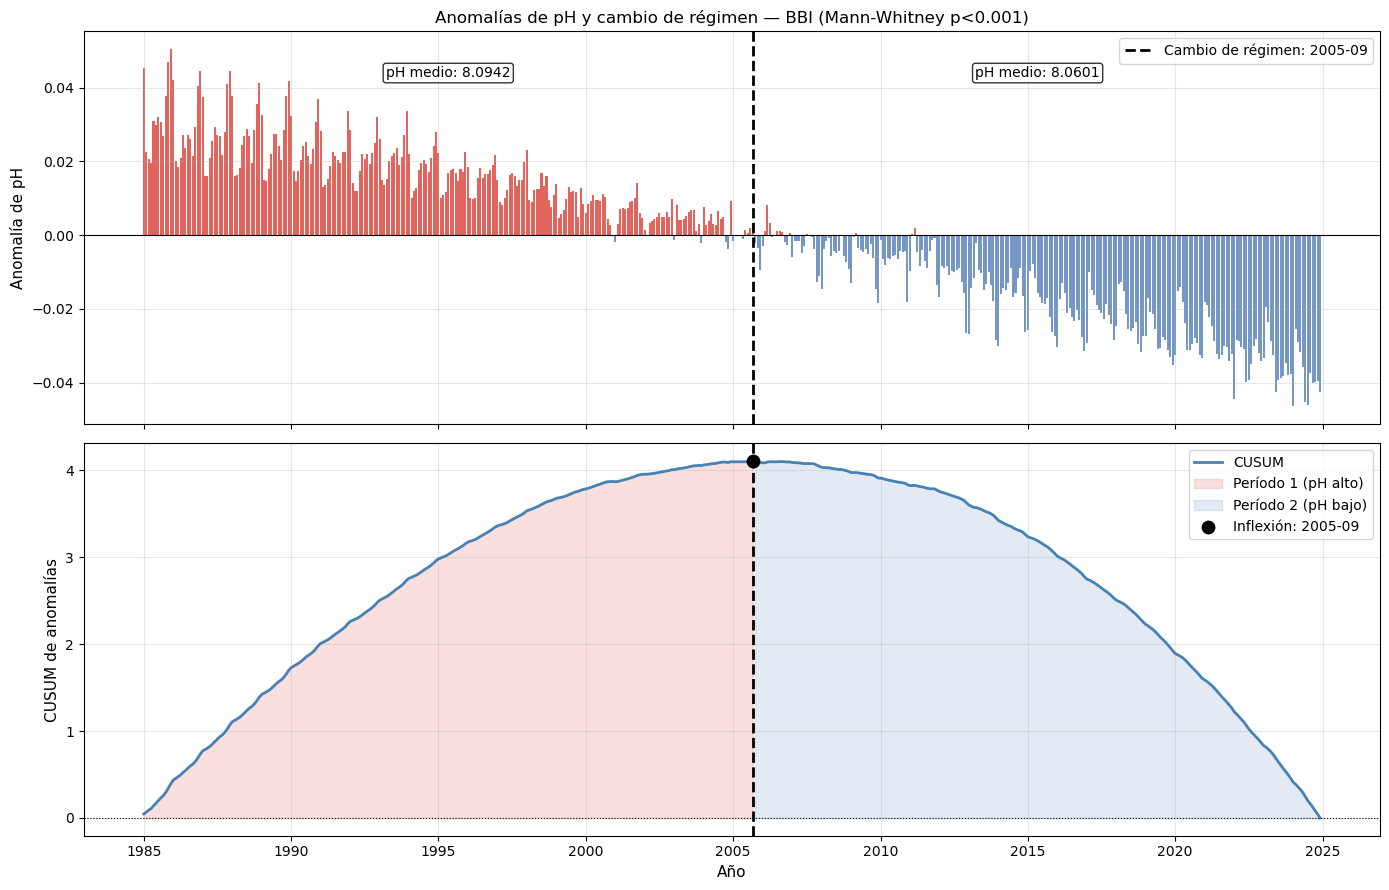

✅ Figura guardada: cusum_BBI.png


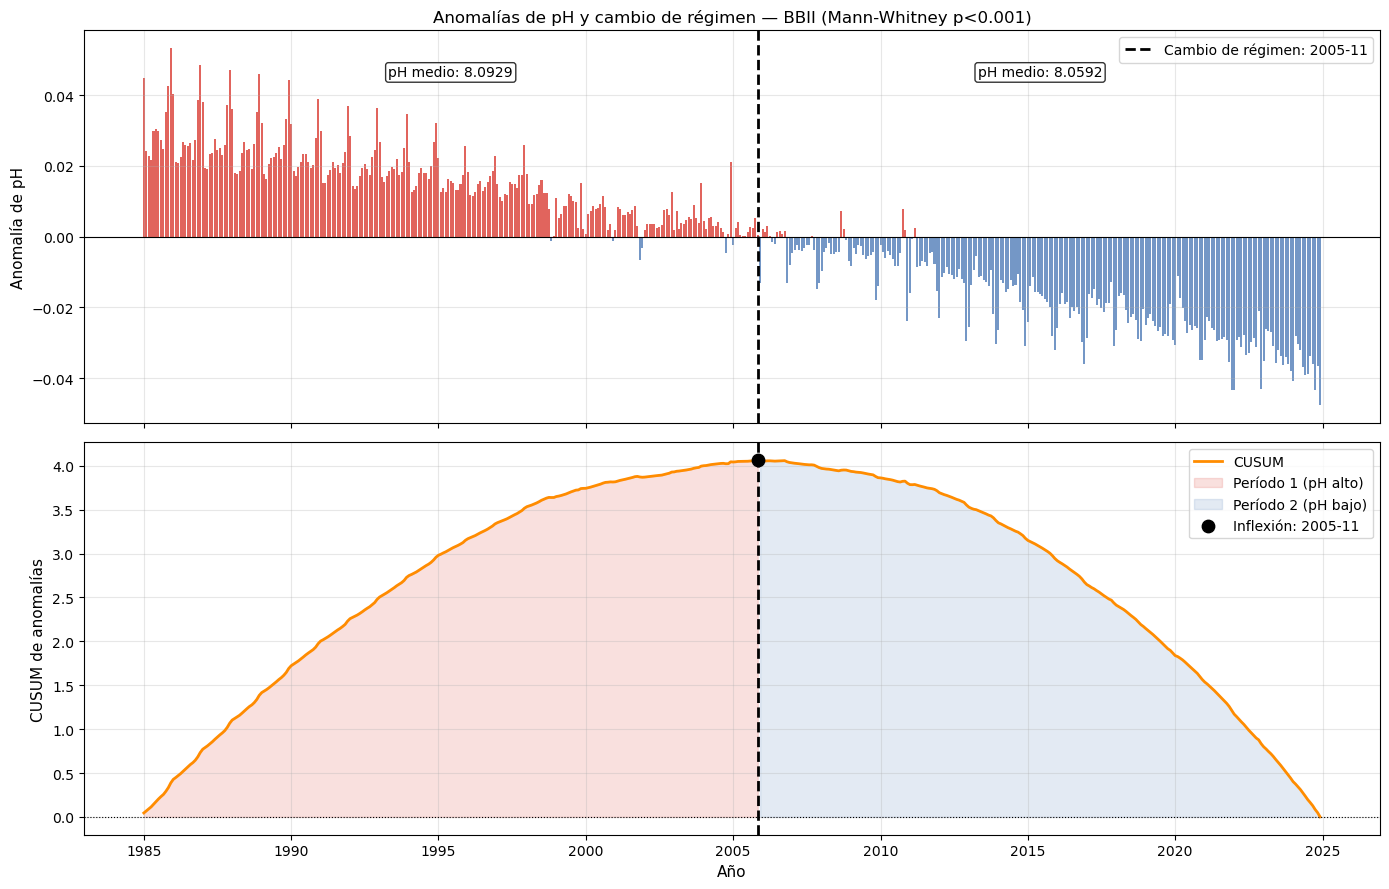

✅ Figura guardada: cusum_BBII.png


In [21]:
# =============================================================================
# CELDA C — Figura publicable: anomalías + CUSUM + punto de cambio
# =============================================================================
 
def plot_cusum_analysis(df_anom, cusum, idx_change, t_change,
                        periods, region_name, color):
    """
    Figura de dos paneles:
        Superior : anomalías mensuales coloreadas por signo +
                   línea vertical del punto de cambio de régimen
        Inferior : curva CUSUM con el punto de inflexión marcado
                   y sombreado de los dos períodos
    """
    times     = df_anom["time"].values
    anomalies = df_anom["anomaly"].values
    t_pd      = pd.to_datetime(times)
 
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
 
    # --- Panel 1: Anomalías ---
    colors_bar = ["#d73027" if v > 0 else "#4575b4" for v in anomalies]
    axes[0].bar(t_pd, anomalies, color=colors_bar, alpha=0.75, width=25)
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].axvline(t_change, color="black", lw=2, linestyle="--",
                    label=f"Cambio de régimen: {t_change.strftime('%Y-%m')}")
 
    # Anotar medias de cada período
    t1_mid = t_pd[t_pd <= t_change].mean()
    t2_mid = t_pd[t_pd >  t_change].mean()
    axes[0].annotate(f"pH medio: {periods['mean1']:.4f}",
                     xy=(t1_mid, anomalies.max()*0.85),
                     ha="center", fontsize=10,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
    axes[0].annotate(f"pH medio: {periods['mean2']:.4f}",
                     xy=(t2_mid, anomalies.max()*0.85),
                     ha="center", fontsize=10,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
 
    sig = "p<0.001" if periods["p_mw"] < 0.001 else "p<0.01" if periods["p_mw"] < 0.01 else "p<0.05"
    axes[0].set_title(
        f"Anomalías de pH y cambio de régimen — {region_name} "
        f"(Mann-Whitney {sig})",
        fontsize=12
    )
    axes[0].set_ylabel("Anomalía de pH", fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)
 
    # --- Panel 2: CUSUM ---
    axes[1].plot(t_pd, cusum, color=color, lw=2, label="CUSUM")
    axes[1].axhline(0, color="black", lw=0.8, linestyle=":")
 
    # Sombrear los dos períodos
    axes[1].fill_between(t_pd, cusum, 0,
                         where=(t_pd <= t_change),
                         alpha=0.15, color="#d73027", label="Período 1 (pH alto)")
    axes[1].fill_between(t_pd, cusum, 0,
                         where=(t_pd > t_change),
                         alpha=0.15, color="#4575b4", label="Período 2 (pH bajo)")
 
    # Marcar punto de inflexión
    axes[1].axvline(t_change, color="black", lw=2, linestyle="--")
    axes[1].scatter([t_change], [cusum[idx_change]],
                    color="black", zorder=5, s=80,
                    label=f"Inflexión: {t_change.strftime('%Y-%m')}")
 
    axes[1].set_ylabel("CUSUM de anomalías", fontsize=11)
    axes[1].set_xlabel("Año", fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3)
 
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURES_DIR, f"cusum_{region_name}.png"),
        dpi=300, bbox_inches="tight"
    )
    plt.show()
    print(f"✅ Figura guardada: cusum_{region_name}.png")
 
 
plot_cusum_analysis(df_BBI_anom,  cusum_BBI,  idx_BBI,  t_change_BBI,
                    periods_BBI,  "BBI",  color="steelblue")
plot_cusum_analysis(df_BBII_anom, cusum_BBII, idx_BBII, t_change_BBII,
                    periods_BBII, "BBII", color="darkorange")
 

Fase ascendente (1985 → 2005, zona rosa):
Los meses con pH alto superan a los meses con pH bajo de forma consistente → la suma sigue acumulando hacia arriba → el océano está en un régimen de pH relativamente alto

Punto de inflexión (2005-09, punto negro):
Es el momento donde el balance cambia → hasta ahí habían dominado las anomalías positivas, a partir de ahí empiezan a dominar las negativas

Fase descendente (2005 → 2024, zona azul):
Los meses con pH bajo superan consistentemente a los altos → la curva cae sostenidamente → el océano entró en un régimen de pH sistemáticamente más bajo


#### Climatología post-quiebre CUSUM (2005-10 en adelante)

In [6]:
# --- Climatología post-quiebre CUSUM (2005-10 en adelante) ---

CORTE_BBI  = "2005-09"
CORTE_BBII = "2005-11"

for variable in ["pH"]:

    clim_post_BBI  = df_BBI.loc[CORTE_BBI:].groupby("month")[variable].mean()
    clim_post_BBII = df_BBII.loc[CORTE_BBII:].groupby("month")[variable].mean()

    tabla_post = pd.DataFrame({
        "Mes":            meses,
        "BBI_full":       df_BBI.groupby("month")[variable].mean().values.round(4),
        "BBI_post2005":   clim_post_BBI.values.round(4),
        "BBII_full":      df_BBII.groupby("month")[variable].mean().values.round(4),
        "BBII_post2005":  clim_post_BBII.values.round(4),
    })
    tabla_post["Δ_BBI"]  = (tabla_post["BBI_post2005"]  - tabla_post["BBI_full"]).round(4)
    tabla_post["Δ_BBII"] = (tabla_post["BBII_post2005"] - tabla_post["BBII_full"]).round(4)

    print(f"\n=== {variable} — Climatología full vs post-quiebre (2005) ===")
    print(tabla_post.to_string(index=False))
    print(f"  BBI  post-2005: min={clim_post_BBI.min():.4f} ({meses[clim_post_BBI.values.argmin()]}) | max={clim_post_BBI.max():.4f} ({meses[clim_post_BBI.values.argmax()]})")
    print(f"  BBII post-2005: min={clim_post_BBII.min():.4f} ({meses[clim_post_BBII.values.argmin()]}) | max={clim_post_BBII.max():.4f} ({meses[clim_post_BBII.values.argmax()]})")


=== pH — Climatología full vs post-quiebre (2005) ===
Mes  BBI_full  BBI_post2005  BBII_full  BBII_post2005   Δ_BBI  Δ_BBII
Ene    8.1021        8.0834     8.0955         8.0774 -0.0187 -0.0181
Feb    8.0836        8.0743     8.0778         8.0673 -0.0093 -0.0105
Mar    8.0825        8.0733     8.0767         8.0664 -0.0092 -0.0103
Abr    8.0761        8.0657     8.0732         8.0618 -0.0104 -0.0114
May    8.0718        8.0584     8.0717         8.0587 -0.0134 -0.0130
Jun    8.0717        8.0568     8.0701         8.0560 -0.0149 -0.0141
Jul    8.0661        8.0509     8.0661         8.0524 -0.0152 -0.0137
Ago    8.0663        8.0517     8.0640         8.0504 -0.0146 -0.0136
Sep    8.0614        8.0485     8.0638         8.0516 -0.0129 -0.0122
Oct    8.0741        8.0603     8.0767         8.0641 -0.0138 -0.0126
Nov    8.0855        8.0686     8.0874         8.0713 -0.0169 -0.0161
Dic    8.0927        8.0731     8.0987         8.0781 -0.0196 -0.0206
  BBI  post-2005: min=8.0485 (Sep) 

#### Resumen actualizado

In [22]:
# =============================================================================
# CELDA D — Resumen actualizado para el paper
# =============================================================================
 
print("\n" + "="*60)
print("  RESUMEN COMPLETO PARA EL PAPER")
print("="*60)
 
for res, per, name in [
    (results_BBI,  periods_BBI,  "BBI"),
    (results_BBII, periods_BBII, "BBII"),
]:
    sig_mk = "p<0.001" if res["mk_p"] < 0.001 else "p<0.01" if res["mk_p"] < 0.01 else "p<0.05"
    sig_mw = "p<0.001" if per["p_mw"] < 0.001 else "p<0.01" if per["p_mw"] < 0.01 else "p<0.05"
    print(f"\n  {name}:")
    print(f"    Tasa de cambio  : {res['slope_dec']:.4f} pH/década ({sig_mk})")
    print(f"    IC 95%          : [{res['IC_low_yr']*10:.4f}, {res['IC_high_yr']*10:.4f}] pH/década")
    print(f"    Cambio régimen  : {per['t1_end']} → {per['t2_start']}")
    print(f"    pH medio P1     : {per['mean1']:.4f}  ({per['t1_start']}–{per['t1_end']})")
    print(f"    pH medio P2     : {per['mean2']:.4f}  ({per['t2_start']}–{per['t2_end']})")
    print(f"    Diferencia P2-P1: {per['diff']:.4f} pH ({sig_mw})")
 


  RESUMEN COMPLETO PARA EL PAPER

  BBI:
    Tasa de cambio  : -0.0173 pH/década (p<0.001)
    IC 95%          : [-0.0175, -0.0172] pH/década
    Cambio régimen  : 2005-09 → 2005-10
    pH medio P1     : 8.0942  (1985-01–2005-09)
    pH medio P2     : 8.0601  (2005-10–2024-12)
    Diferencia P2-P1: -0.0341 pH (p<0.001)

  BBII:
    Tasa de cambio  : -0.0172 pH/década (p<0.001)
    IC 95%          : [-0.0173, -0.0170] pH/década
    Cambio régimen  : 2005-11 → 2005-12
    pH medio P1     : 8.0929  (1985-01–2005-11)
    pH medio P2     : 8.0592  (2005-12–2024-12)
    Diferencia P2-P1: -0.0337 pH (p<0.001)


#### Figura publicable

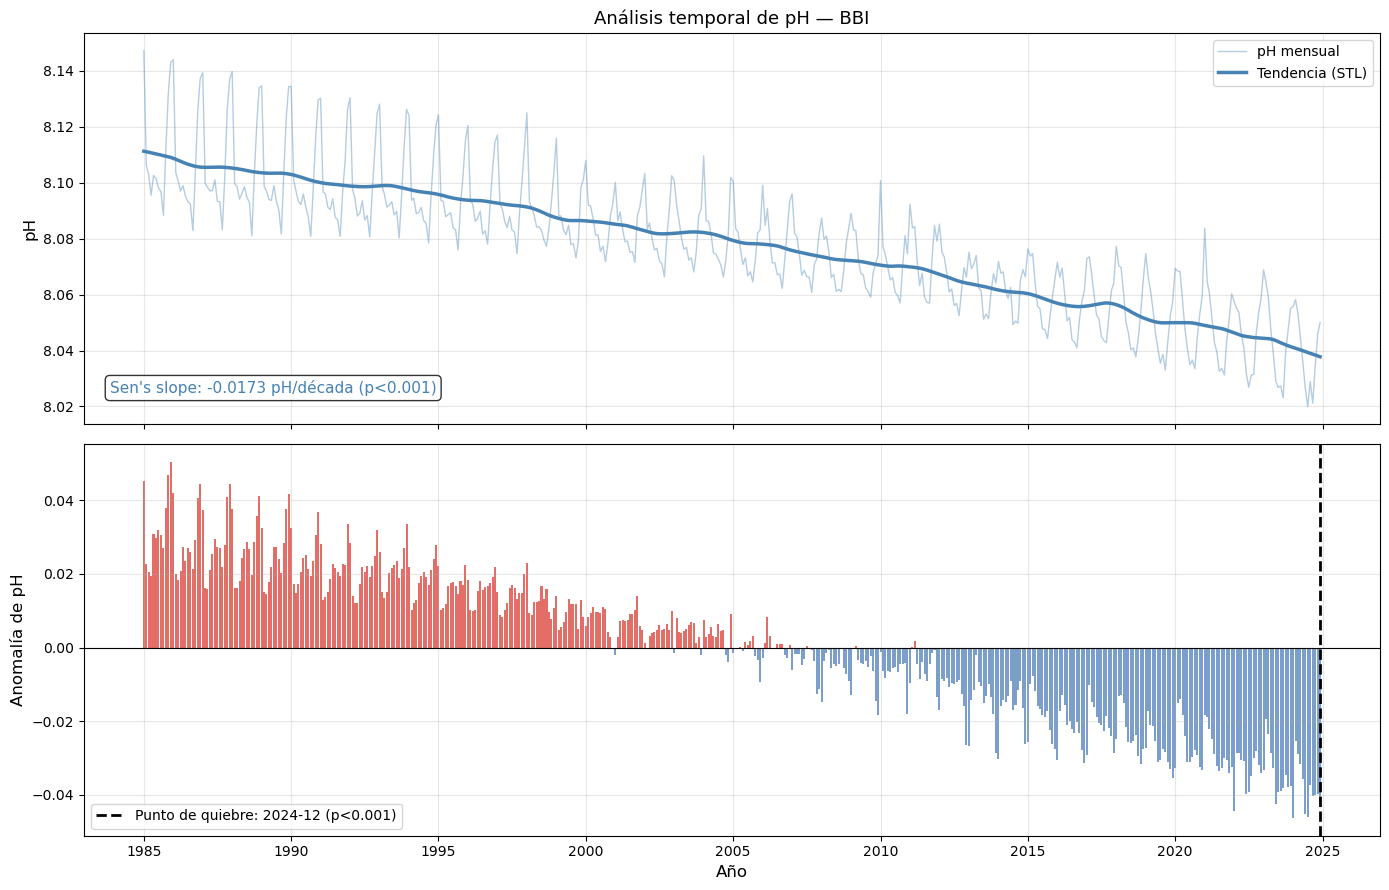

✅ Figura guardada: ph_analysis_BBI.png


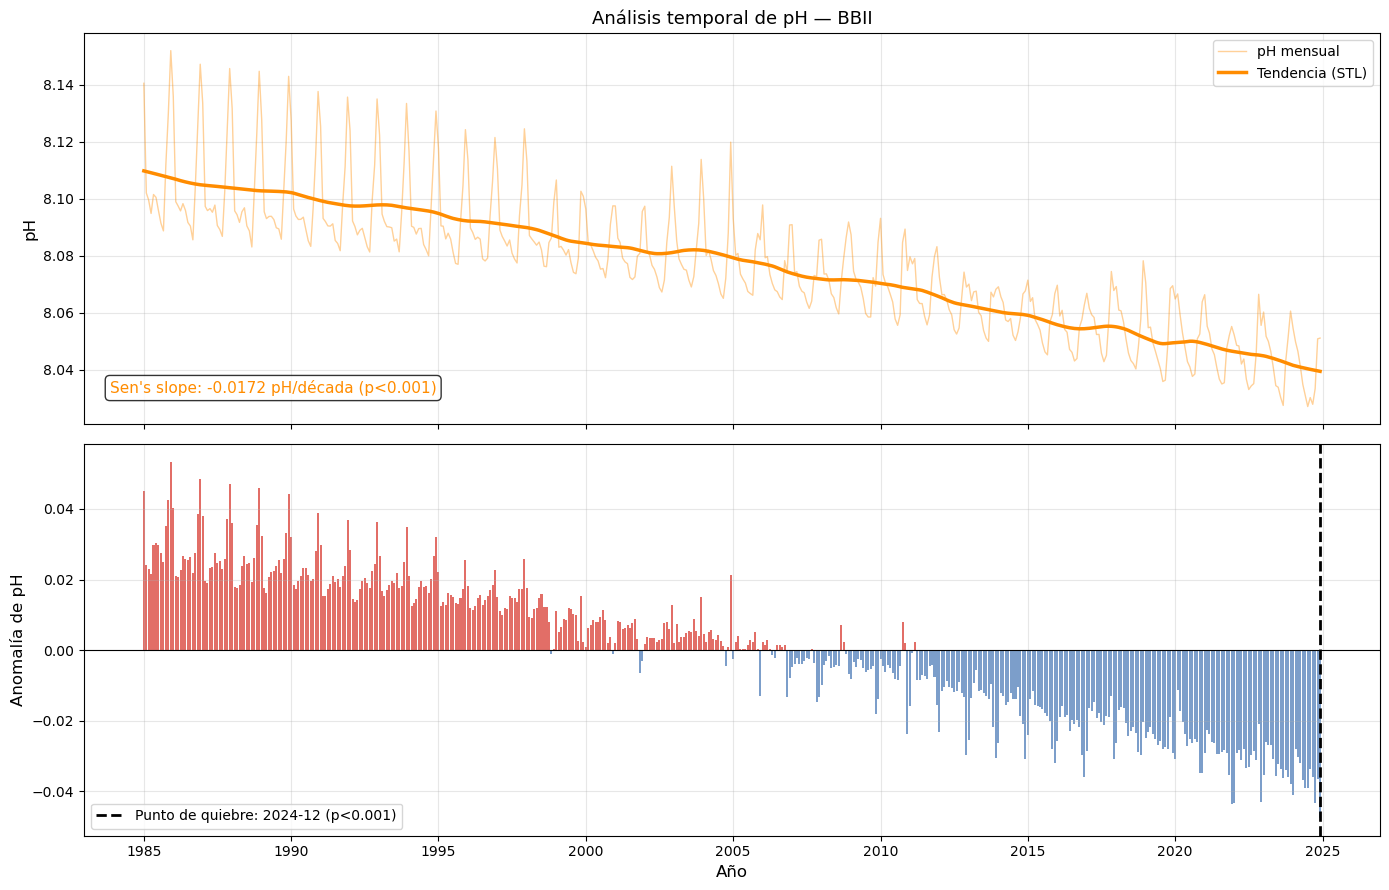

✅ Figura guardada: ph_analysis_BBII.png


In [11]:
# =============================================================================
# CELDA 8 — Paso 6: Figura publicable
# =============================================================================
 
# Figura principal del análisis temporal:
# Panel superior  : serie mensual + componente de tendencia STL
# Panel inferior  : anomalías mensuales + punto de quiebre (Pettitt)
# Una figura por región (BBI y BBII)
 
def plot_analysis(df_stl, df_anom, results, t_change, p_pettitt, region_name, color):
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
 
    # --- Panel 1: serie mensual + tendencia STL ---
    axes[0].plot(df_stl["time"], df_stl["pH"],
                 color=color, alpha=0.4, lw=1, label="pH mensual")
    axes[0].plot(df_stl["time"], df_stl["trend"],
                 color=color, lw=2.5, label="Tendencia (STL)")
 
    # Anotar tasa de cambio
    slope_dec = results["slope_dec"]
    p_mk      = results["mk_p"]
    sig_str   = "p<0.001" if p_mk < 0.001 else "p<0.01" if p_mk < 0.01 else "p<0.05"
    axes[0].annotate(
        f"Sen's slope: {slope_dec:.4f} pH/década ({sig_str})",
        xy=(0.02, 0.08), xycoords="axes fraction",
        fontsize=11, color=color,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
    )
 
    axes[0].set_ylabel("pH", fontsize=12)
    axes[0].set_title(f"Análisis temporal de pH — {region_name}", fontsize=13)
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)
 
    # --- Panel 2: anomalías + punto de quiebre ---
    anomalies = df_anom["anomaly"]
    times     = df_anom["time"]
 
    # Barras coloreadas por signo
    colors_bar = ["#d73027" if v > 0 else "#4575b4" for v in anomalies]
    axes[1].bar(times, anomalies, color=colors_bar, alpha=0.7, width=25)
 
    # Línea del punto de quiebre
    sig_pett = "p<0.001" if p_pettitt < 0.001 else "p<0.01" if p_pettitt < 0.01 else "p<0.05"
    axes[1].axvline(t_change, color="black", lw=2, linestyle="--",
                    label=f"Punto de quiebre: {t_change.strftime('%Y-%m')} ({sig_pett})")
 
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_ylabel("Anomalía de pH", fontsize=12)
    axes[1].set_xlabel("Año", fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3)
 
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"ph_analysis_{region_name}.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ Figura guardada: ph_analysis_{region_name}.png")
 
 
plot_analysis(df_BBI_stl,  df_BBI_anom,  results_BBI,  t_change_BBI,
              p_BBI,  "BBI",  color="steelblue")
 
plot_analysis(df_BBII_stl, df_BBII_anom, results_BBII, t_change_BBII,
              p_BBII, "BBII", color="darkorange")

In [12]:
# =============================================================================
# CELDA 9 — Resumen de resultados para el paper
# =============================================================================
 
print("\n" + "="*60)
print("  RESUMEN PARA EL PAPER")
print("="*60)
 
for res, t_ch, p_pett, name in [
    (results_BBI,  t_change_BBI,  p_BBI,  "BBI"),
    (results_BBII, t_change_BBII, p_BBII, "BBII"),
]:
    print(f"\n  {name}:")
    print(f"    Tasa de cambio : {res['slope_dec']:.4f} pH/década")
    print(f"    IC 95%         : [{res['IC_low_yr']*10:.4f}, {res['IC_high_yr']*10:.4f}] pH/década")
    print(f"    Mann-Kendall   : {res['mk_trend']}, p = {res['mk_p']:.2e}")
    print(f"    Punto quiebre  : {t_ch.strftime('%Y-%m')}, p = {p_pett:.2e}")
 


  RESUMEN PARA EL PAPER

  BBI:
    Tasa de cambio : -0.0173 pH/década
    IC 95%         : [-0.0175, -0.0172] pH/década
    Mann-Kendall   : decreasing, p = 0.00e+00
    Punto quiebre  : 2024-12, p = 1.34e-222

  BBII:
    Tasa de cambio : -0.0172 pH/década
    IC 95%         : [-0.0173, -0.0170] pH/década
    Mann-Kendall   : decreasing, p = 0.00e+00
    Punto quiebre  : 2024-12, p = 2.97e-223
